In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_curve, roc_auc_score

DataSet Import


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cardio_train.csv to cardio_train.csv


In [ ]:
df = pd.read_csv("cardio_train.csv", sep=";")

In [ ]:
#!pip install ydata-profiling

In [ ]:
list(df.columns)

['id',
 'age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio']

In [ ]:
pd.concat([df.head(5), df.sample(5), df.tail(5)])

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
38290,54655,15798,2,160,60.0,110,70,2,1,0,0,1,0
44017,62886,18978,1,168,70.0,120,80,1,1,0,0,1,0
48606,69405,18253,1,158,77.0,140,90,3,1,0,0,1,1
11381,16279,20227,1,162,78.0,150,100,1,1,0,0,1,1
57464,82013,18279,1,161,60.0,110,70,2,1,0,0,1,0


In [ ]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


Preprocessing

In [ ]:
pd.DataFrame([ df.nunique(), df.dtypes ], index=['Unique Values', 'Data Types'])

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
Unique Values,70000,8076,2,109,287,153,157,3,3,2,2,2,2
Data Types,int64,int64,int64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64


In [ ]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [ ]:
TARGET = 'cardio'
INPUT_FEATURES = ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active']

In [ ]:
pd.DataFrame([ df.nunique(), df.dtypes ])

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,70000,8076,2,109,287,153,157,3,3,2,2,2,2
1,int64,int64,int64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
pd.DataFrame(
    {
    "Count" : df.isna().sum().sort_values(ascending=False),
    "percent %" : 100.0 * df.isna().sum().sort_values(ascending=False) / len(df),
    }
).T

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
Count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
percent %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def drop_unnwanted_features(df, features_to_drop):
    print(f"Dropping features: {features_to_drop}")

    if features_to_drop in list(df.columns):
        df = df.drop(columns=features_to_drop)

    if features_to_drop in INPUT_FEATURES:
        INPUT_FEATURES.remove(features_to_drop)
    return df

In [ ]:
df = drop_unnwanted_features(df, 'id')
list(df.columns)

Dropping features: id


['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio']

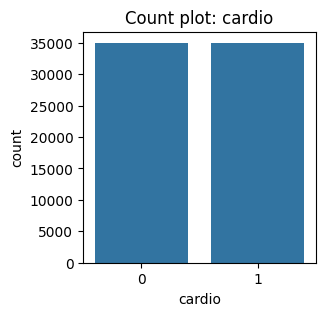

In [ ]:
plt.figure(figsize=(3,3))
plt.title(f"Count plot: {TARGET}")
sns.countplot(df, x=TARGET)
plt.show()

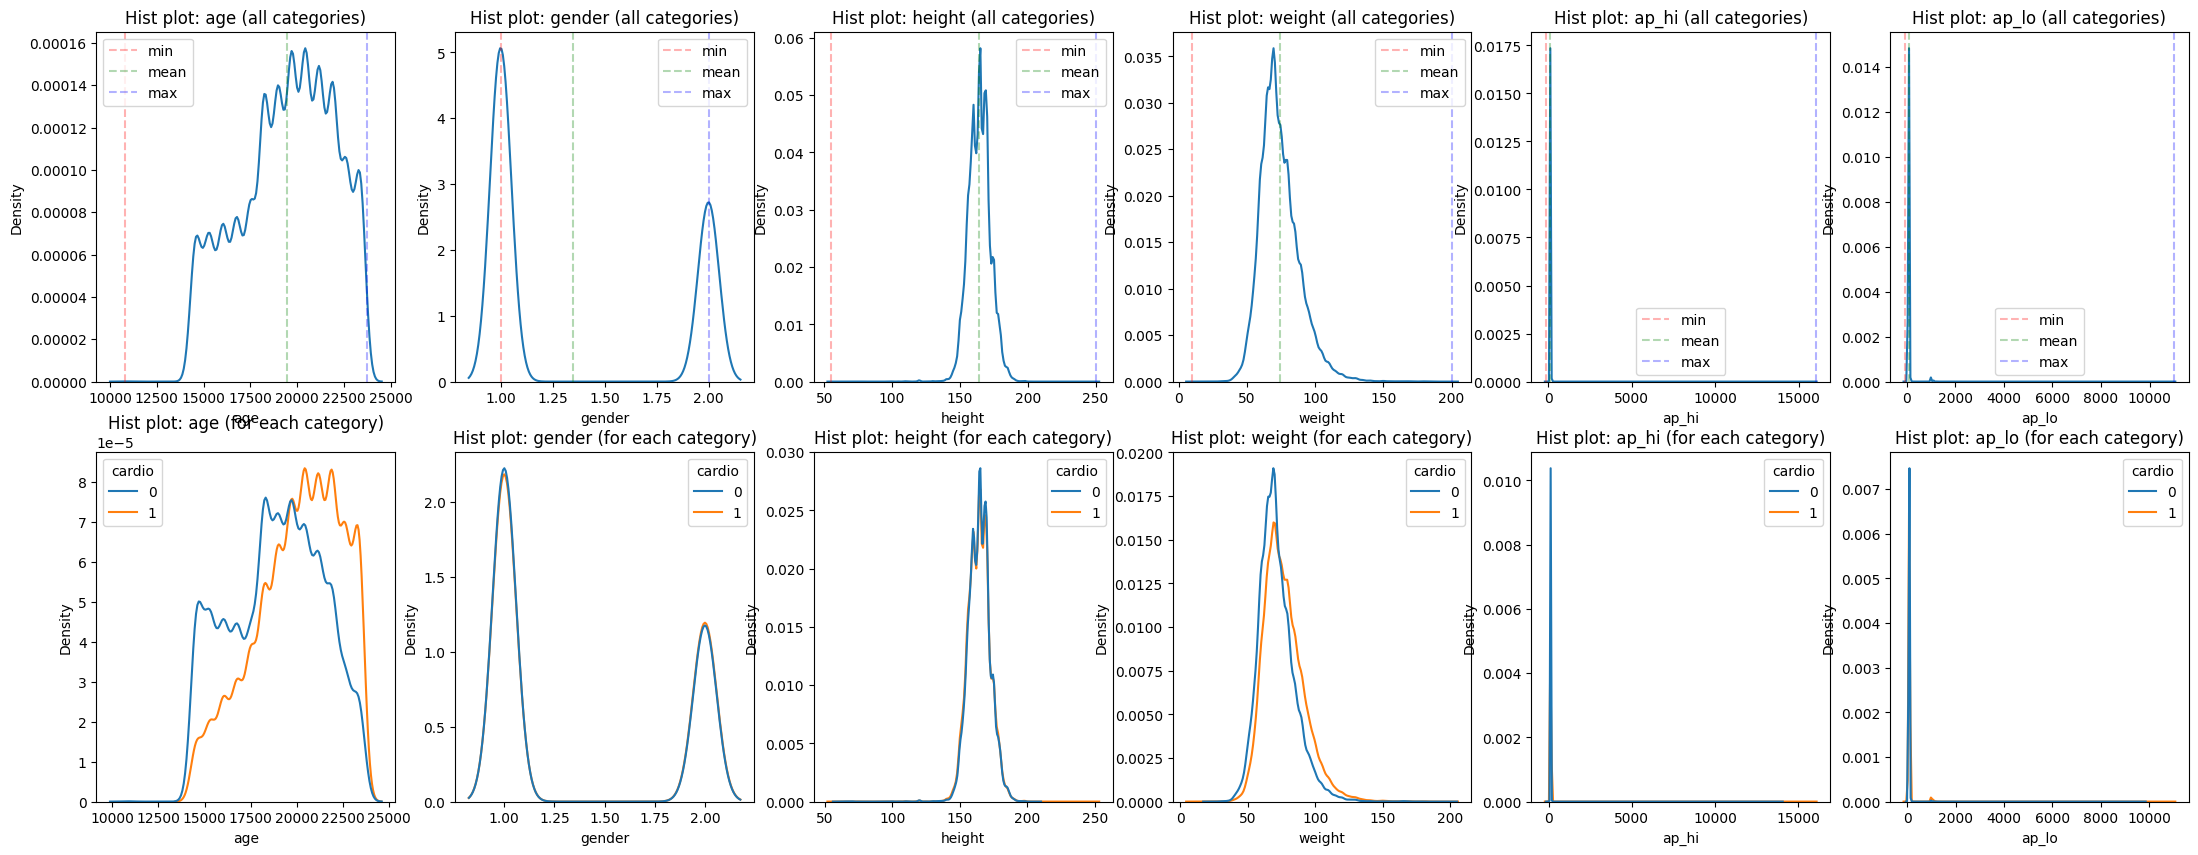

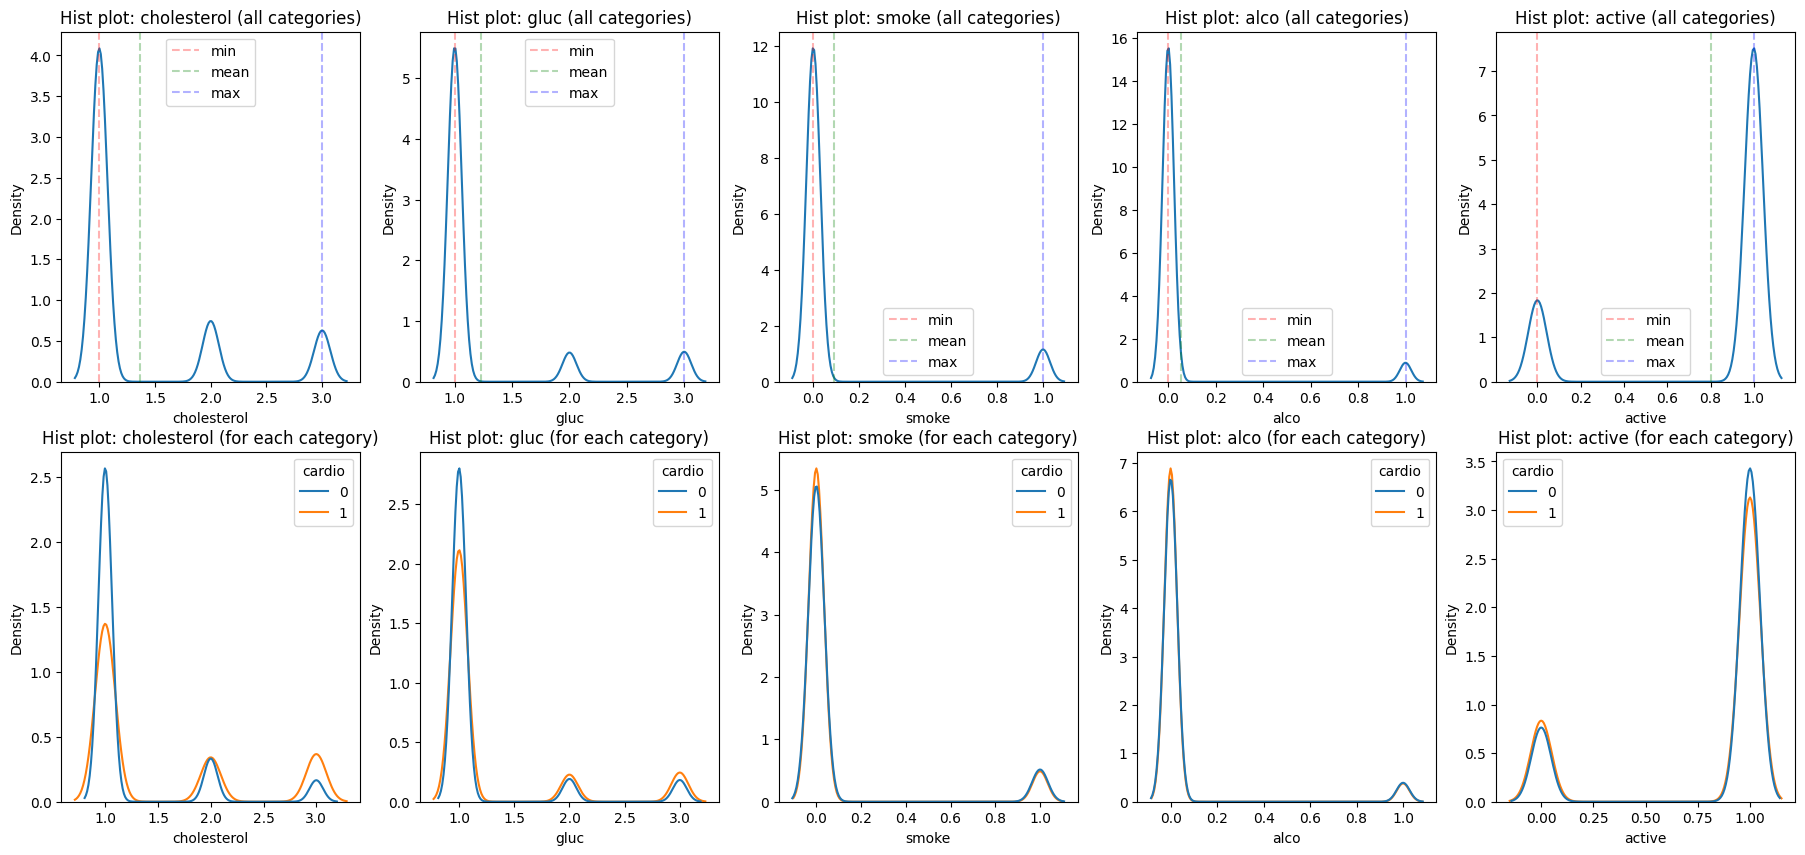

In [ ]:
ROW_WIDTH = 6
temp = 0

for num_feature in INPUT_FEATURES:
    if temp == 0:
        plt.figure(figsize=(27,10))

    plt.subplot(2,ROW_WIDTH, temp + 1)
    plt.title(f"Hist plot: {num_feature} (all categories)")
    sns.kdeplot(df, x=num_feature, )

    plt.axvline(x= df[num_feature].min() , label="min", color='r', linestyle='--', alpha = 0.3)
    plt.axvline(x= df[num_feature].mean() , label="mean", color='g', linestyle='--', alpha = 0.3)
    plt.axvline(x= df[num_feature].max() , label="max", color='b', linestyle='--', alpha = 0.3)

    plt.legend()


    plt.subplot(2,ROW_WIDTH, (temp + 1) + ROW_WIDTH)
    plt.title(f"Hist plot: {num_feature} (for each category)")
    sns.kdeplot(df, x=num_feature, hue=TARGET, palette='tab10')

    if temp == ROW_WIDTH - 1:
        plt.show()

    temp = (temp + 1) % ROW_WIDTH

if temp != ROW_WIDTH - 1:
    plt.show()

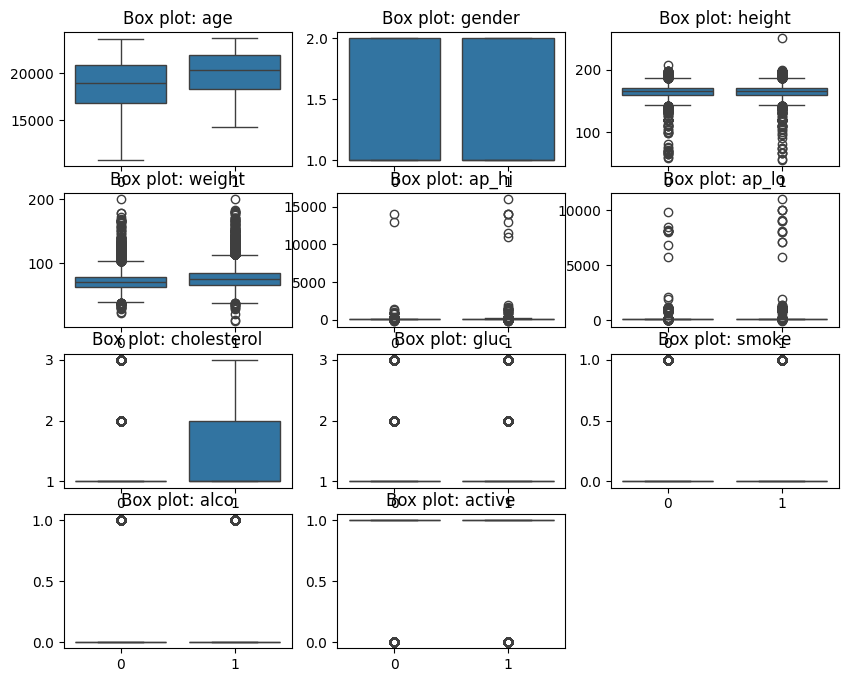

In [ ]:
import math
N_COLS = 3
N_ROWS = math.ceil(len(INPUT_FEATURES) / N_COLS)

plt.figure(figsize=(10,8))

for i, feature in enumerate(INPUT_FEATURES):
    plt.subplot(N_ROWS, N_COLS, i+1)
    plt.title(f"Box plot: {feature}")
    sns.boxplot(df, x=TARGET, y=feature)
    plt.ylabel("")
    plt.xlabel('')

plt.show()

In [ ]:
def plot_box(features, hue):
    ROW_WIDTH = 6
    temp = 0

    for num_feature in features:
        if temp == 0:
            plt.figure(figsize=(25,5))

        plt.subplot(1,ROW_WIDTH, temp + 1)
        plt.title(f"Box plot: {num_feature}")
        sns.boxplot(df, x=num_feature, hue=hue, palette='rocket')

        if temp == ROW_WIDTH - 1:
            plt.show()

        temp = (temp + 1) % ROW_WIDTH

    if temp != ROW_WIDTH - 1:
        plt.show()


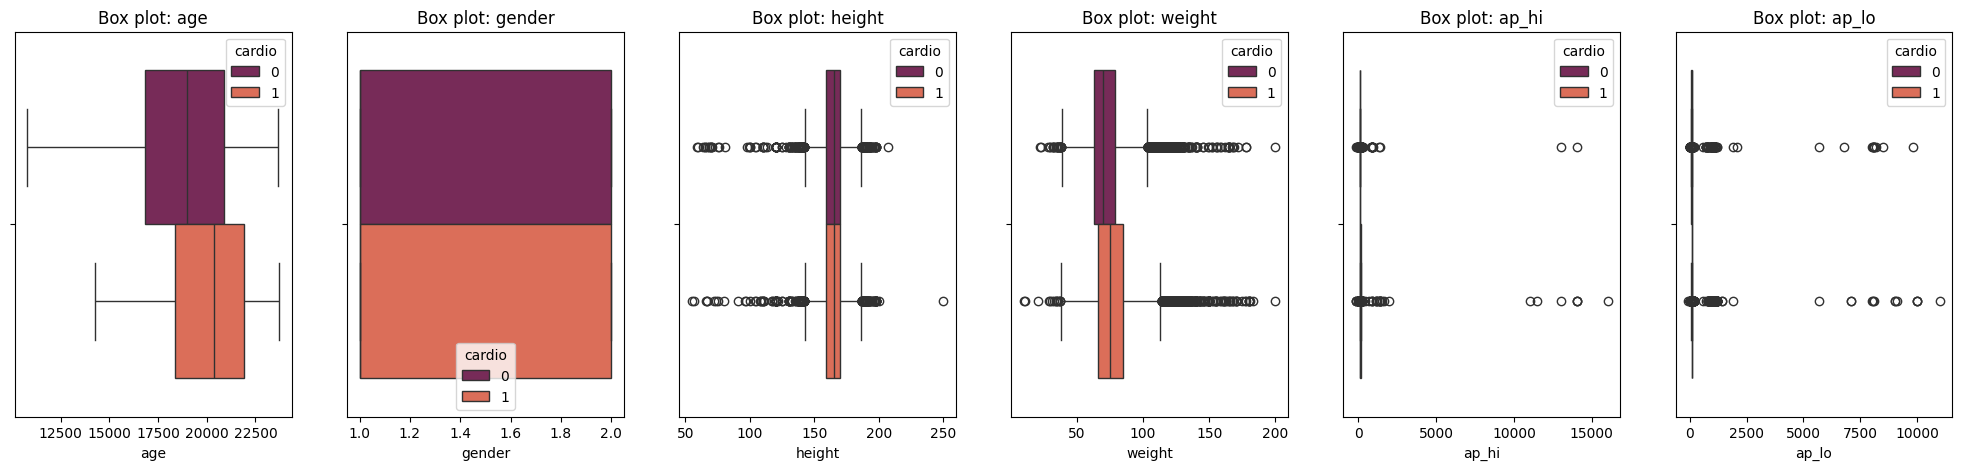

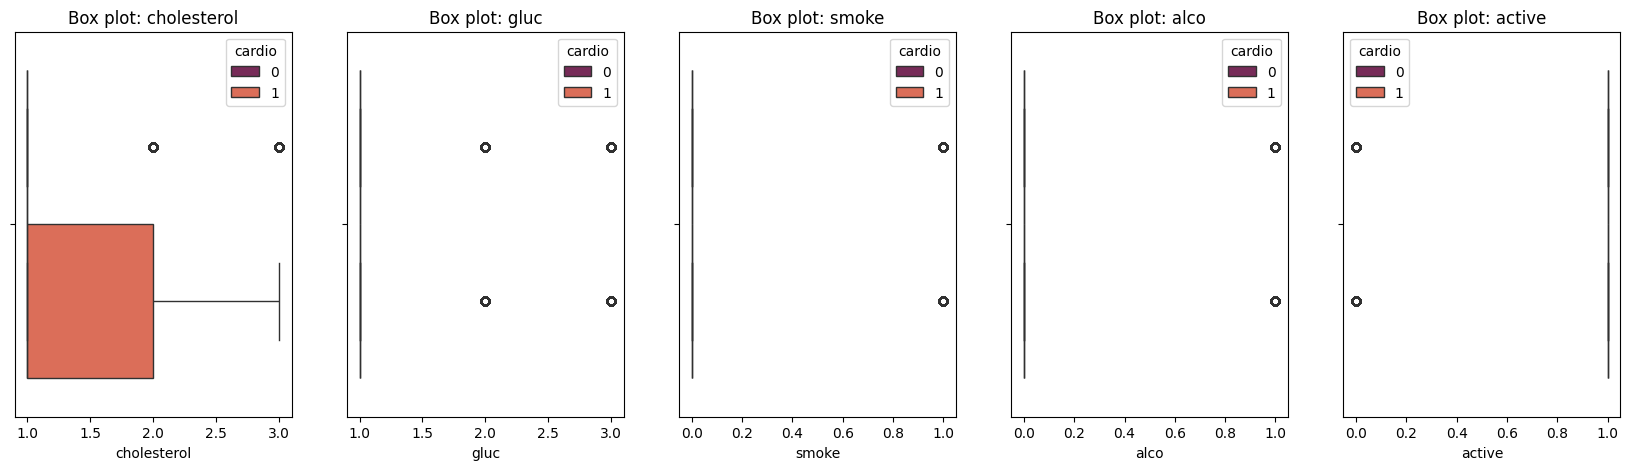

In [ ]:
plot_box(INPUT_FEATURES, TARGET)

In [ ]:
def IQR(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    min_v = Q1 - 1.5 * IQR
    max_v = Q3 + 1.5 * IQR

    return series.clip(lower=min_v, upper=max_v)

In [ ]:
exclude = ['gluc','alco','smoke','colesterol','active']

for num_feature in [f for f in INPUT_FEATURES if f not in exclude]:
    for gender_category in df[TARGET].unique():
        mask = df[TARGET] == gender_category
        df.loc[mask, num_feature] = IQR(df.loc[mask, num_feature])

/tmp/ipykernel_2223/160621486.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[168. 156. 151. ... 159. 168. 170.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, num_feature] = IQR(df.loc[mask, num_feature])


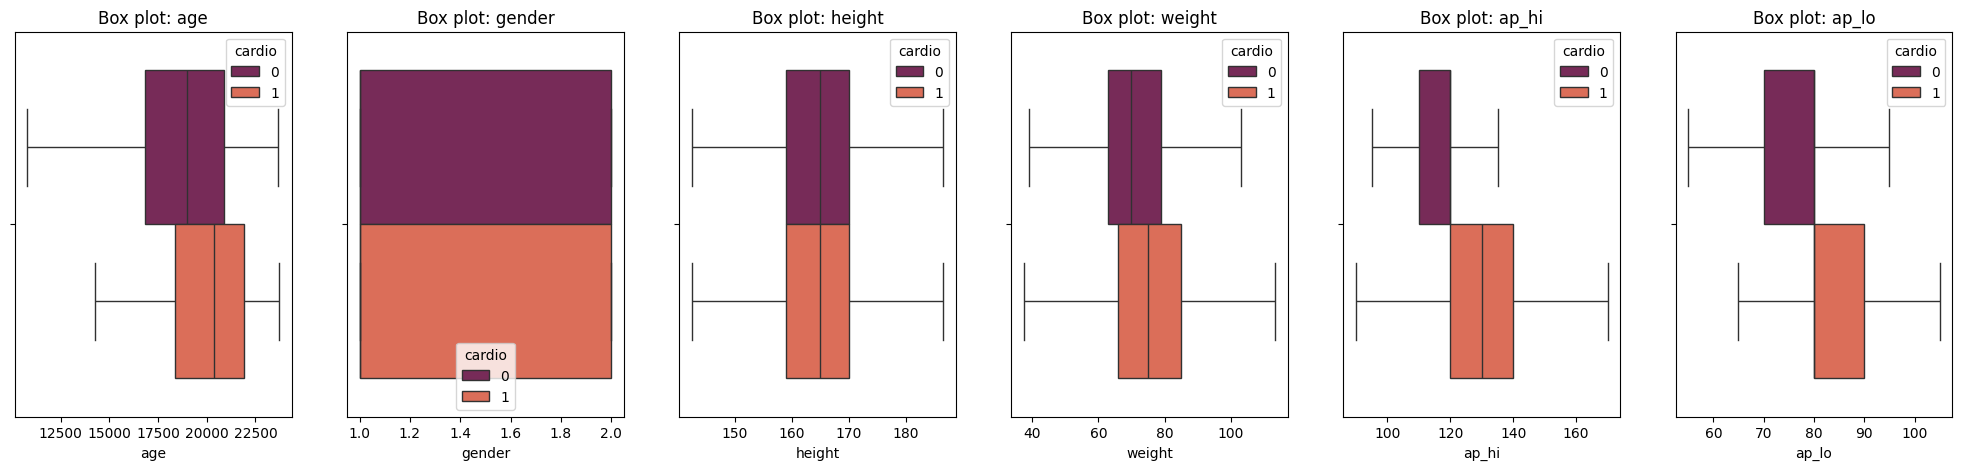

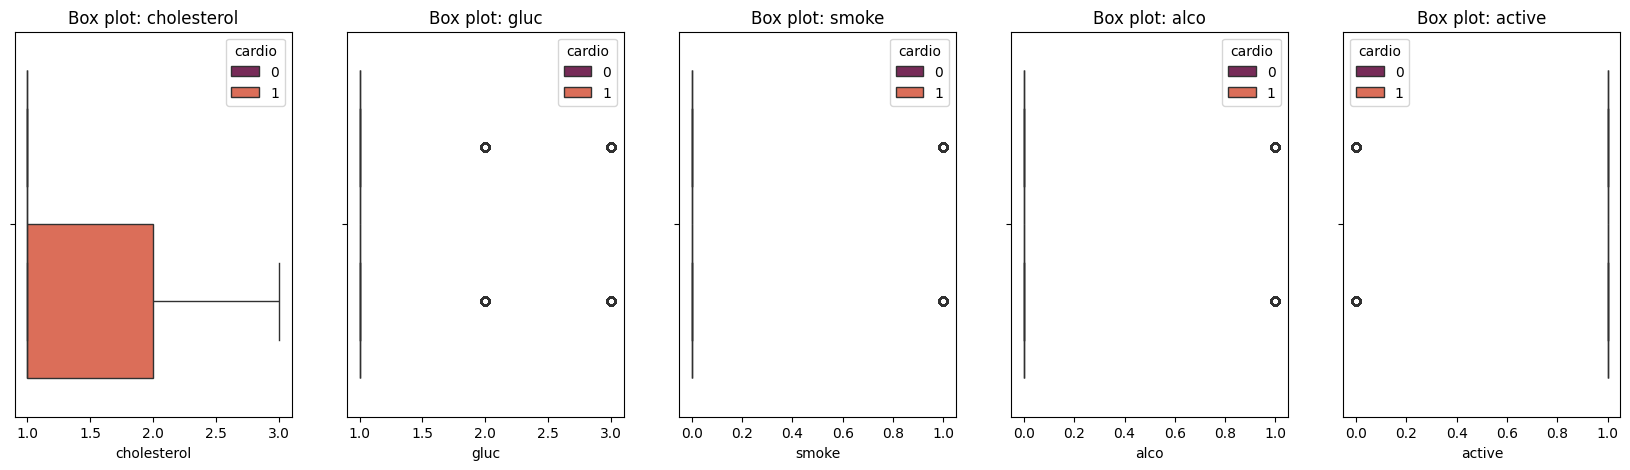

In [ ]:
plot_box(INPUT_FEATURES, TARGET)

In [ ]:
INPUT_FEATURES

['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active']

In [ ]:
df['age_years'] = (df['age'] / 365).round().astype(int)
df['height'] = df['height'] / 100
df['bmi'] = df['weight'] / (df['height'] ** 2)
df['pulse_pressure']=df['ap_hi']-df['ap_lo']
df['health_index'] = (df['active'] * 1) - (df['smoke'] * 0.5) - (df['alco'] * 0.5)
df['cholesterol_gluc_interaction'] = df['cholesterol'] * df['gluc']
df["map"] = df["ap_lo"] + (df["ap_hi"] - df["ap_lo"]) / 3

def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    elif bmi < 35:
        return 3
    elif bmi < 40:
        return 4
    else:
        return 5

df["bmi_category"] = df["bmi"].apply(bmi_category)
# MAP Category
def map_category(x):
    if x < 70:
        return 0
    elif x < 80:
        return 1
    elif x < 90:
        return 2
    elif x < 100:
        return 3
    elif x < 110:
        return 4
    else:
        return 5

df["map_category"] = df["map"].apply(map_category)
def age_category(age):
    if age < 40:
        return 0
    elif age < 45:
        return 1
    elif age < 50:
        return 2
    elif age < 55:
        return 3
    elif age < 60:
        return 4
    elif age < 65:
        return 5
    else:
        return 6

df["age_category"] = df["age_years"].apply(age_category)
def bp_category(row):

    ap_hi = row["ap_hi"]
    ap_lo = row["ap_lo"]

    # Normal
    if ap_hi < 120 and ap_lo < 80:
        return 0

    # Elevated
    elif 120 <= ap_hi < 130 and ap_lo < 80:
        return 1

    # Stage 1 Hypertension
    elif (130 <= ap_hi < 140) or (80 <= ap_lo < 90):
        return 2

    # Stage 2 Hypertension
    elif (140 <= ap_hi < 180) or (90 <= ap_lo < 120):
        return 3

    # Hypertensive Crisis
    else:
        return 4

df["bp_category"] = df.apply(bp_category, axis=1)

df['metabolic_risk'] = (
    df['cholesterol'] *
    df['gluc'] *
    df['bmi']
)

df['bp_risk'] = (
    df['ap_hi'] *
    df['cholesterol']
)
new_features = [
    'age_years',
    'bmi',
    'pulse_pressure',
    'health_index',
    'cholesterol_gluc_interaction',
    'map',
    'bmi_category',
    'map_category',
    'age_category',
    'bp_category',
    'metabolic_risk',
    'bp_risk'
]
INPUT_FEATURES = INPUT_FEATURES + [f for f in new_features if f not in INPUT_FEATURES]

In [ ]:
print(df["age_category"].value_counts().sort_index())

age_category
0      413
1     9617
2     8719
3    19313
4    16038
5    15548
6      352
Name: count, dtype: int64


In [ ]:
df = drop_unnwanted_features(df, 'age')


Dropping features: age


In [ ]:
df.columns
print(df.shape)

(70000, 23)


In [ ]:
TARGET='cardio'
INPUT_FEATURES=['gender', 'height','weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke',
       'alco', 'active', 'age_years', 'bmi', 'pulse_pressure',
       'health_index', 'cholesterol_gluc_interaction','map','bmi_category','map_category','age_category','bp_category', 'metabolic_risk', 'bp_risk']

In [ ]:
INPUT_FEATURES

['gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'age_years',
 'bmi',
 'pulse_pressure',
 'health_index',
 'cholesterol_gluc_interaction',
 'map',
 'bmi_category',
 'map_category',
 'age_category',
 'bp_category',
 'metabolic_risk',
 'bp_risk']

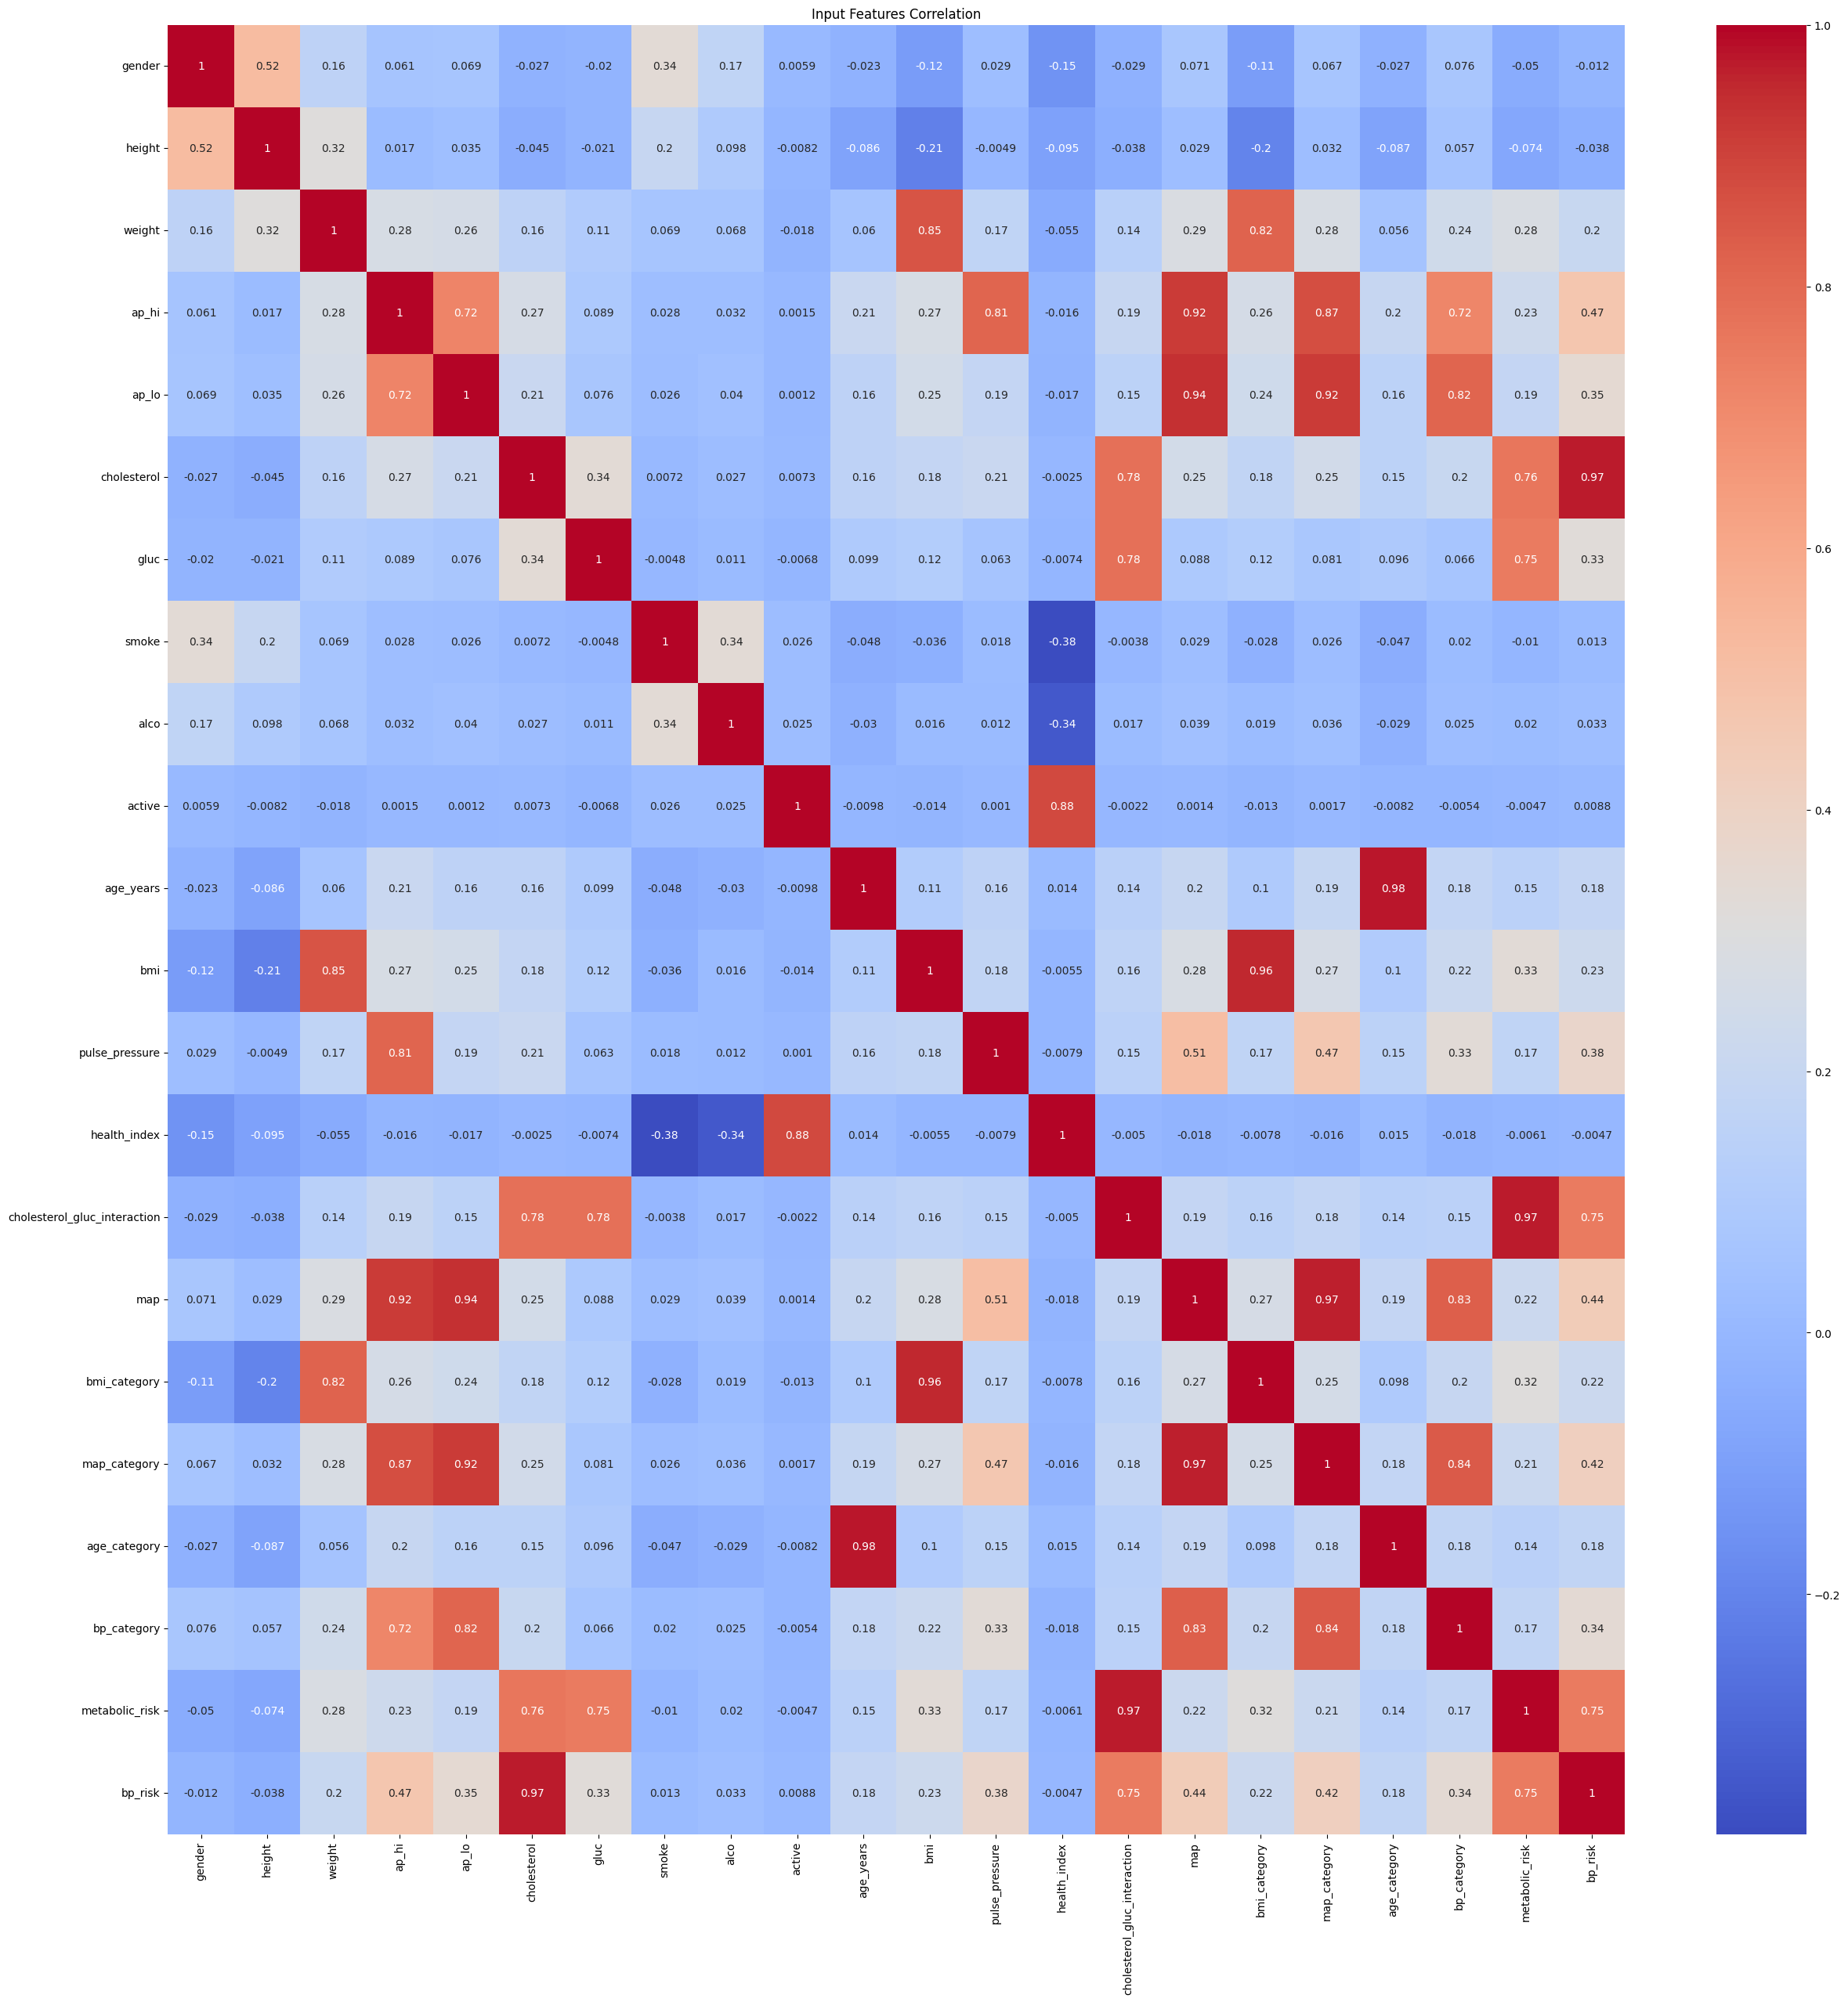

In [ ]:
plt.figure(figsize=(30, 30))

plt.title("Input Features Correlation")

sns.heatmap(
    df[INPUT_FEATURES].corr(),
    annot=True,
    cmap='coolwarm',
    )

plt.show()

In [ ]:
print(df.shape)

print(
    df[['ap_hi','ap_lo','weight','height','bmi']]
    .describe()
)

(70000, 23)
              ap_hi         ap_lo        weight        height           bmi
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000
mean     126.230657     81.527071     73.963974      1.644072     27.402340
std       15.593516      9.240543     13.564876      0.078257      4.982757
min       90.000000     55.000000     37.500000      1.425000     11.835627
25%      120.000000     80.000000     65.000000      1.590000     23.875115
50%      120.000000     80.000000     72.000000      1.650000     26.377898
75%      135.000000     90.000000     82.000000      1.700000     30.120482
max      170.000000    105.000000    113.500000      1.865000     55.894121


In [ ]:
X = df[INPUT_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=1234,
    stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (56000, 22), X_test: (14000, 22)


In [ ]:
print(f"{X_train.shape= }")
print(f"{y_train.shape= }")
print(f"{X_test.shape= }")
print(f"{y_test.shape= }")

X_train.shape= (56000, 22)
y_train.shape= (56000,)
X_test.shape= (14000, 22)
y_test.shape= (14000,)


In [ ]:
y_train.value_counts()

,count
cardio,
0,28017
1,27983


In [ ]:
y_test.value_counts()

,count
cardio,
0,7004
1,6996


In [ ]:
list(X_train.columns)

['gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'age_years',
 'bmi',
 'pulse_pressure',
 'health_index',
 'cholesterol_gluc_interaction',
 'map',
 'bmi_category',
 'map_category',
 'age_category',
 'bp_category',
 'metabolic_risk',
 'bp_risk']

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    criterion="entropy",
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.8254
F1 Score : 0.7996
ROC AUC  : 0.9036


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=1234,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Probability for ROC-AUC
y_prob = rf.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.8285
F1 Score : 0.7977
ROC AUC  : 0.9082


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# Define features and target
X = df[INPUT_FEATURES]
y = df[TARGET]

# Random Forest model
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
# Train
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
# ---- CROSS VALIDATION ----
scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Accuracy: 0.8307142857142857
Cross-validation scores: [0.83278571 0.835      0.8325     0.83278571 0.83385714]
Average CV score: 0.8333857142857143


In [ ]:
from sklearn.metrics import accuracy_score

print("Train Accuracy:",
      accuracy_score(y_train,
                     model.predict(X_train)))

print("Test Accuracy:",
      accuracy_score(y_test,
                     model.predict(X_test)))

Train Accuracy: 0.8395535714285715
Test Accuracy: 0.8307142857142857


In [ ]:
print(model.feature_names_in_)
print(X.columns.tolist())

['gender' 'height' 'weight' 'ap_hi' 'ap_lo' 'cholesterol' 'gluc' 'smoke'
 'alco' 'active' 'age_years' 'bmi' 'pulse_pressure' 'health_index'
 'cholesterol_gluc_interaction' 'map' 'bmi_category' 'map_category'
 'age_category' 'bp_category' 'metabolic_risk' 'bp_risk']
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'pulse_pressure', 'health_index', 'cholesterol_gluc_interaction', 'map', 'bmi_category', 'map_category', 'age_category', 'bp_category', 'metabolic_risk', 'bp_risk']


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.8 MB/s eta 0:00:00


In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def objective(trial):

    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "random_state": 42,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Accuracy:", study.best_value)
print("Best Parameters:")
print(study.best_params)

[I 2026-06-29 11:02:04,343] A new study created in memory with name: no-name-03d6eaf0-9c48-4d77-a13a-4d1ec6811aeb
[I 2026-06-29 11:02:31,552] Trial 0 finished with value: 0.8355178571428572 and parameters: {'max_depth': 10, 'learning_rate': 0.018635514429067156, 'n_estimators': 254, 'subsample': 0.7086899418609438, 'colsample_bytree': 0.7504709293059594, 'min_child_weight': 8, 'gamma': 0.5311756685352009}. Best is trial 0 with value: 0.8355178571428572.
[I 2026-06-29 11:02:40,768] Trial 1 finished with value: 0.8355535714285715 and parameters: {'max_depth': 7, 'learning_rate': 0.1942501483681251, 'n_estimators': 566, 'subsample': 0.8896339412579097, 'colsample_bytree': 0.9766058515753107, 'min_child_weight': 8, 'gamma': 3.823909980205804}. Best is trial 1 with value: 0.8355535714285715.
[I 2026-06-29 11:02:46,660] Trial 2 finished with value: 0.835375 and parameters: {'max_depth': 10, 'learning_rate': 0.23518811419718236, 'n_estimators': 546, 'subsample': 0.9061613347693289, 'colsample

Best Accuracy: 0.8360892857142858
Best Parameters:
{'max_depth': 5, 'learning_rate': 0.1836253695299319, 'n_estimators': 247, 'subsample': 0.8740253933174045, 'colsample_bytree': 0.8222305564765527, 'min_child_weight': 8, 'gamma': 4.760846796118533}


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Features and target
X = df[INPUT_FEATURES]
y = df[TARGET]


# Model
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]
cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=10,
    scoring="accuracy"
)


# Metrics
print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("F1 Score :", round(f1_score(y_test, y_pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob),4))

print("CV Scores:", cv_scores)
print("Average CV:", cv_scores.mean())

Accuracy : 0.8311
F1 Score : 0.8105
ROC-AUC  : 0.9113
CV Scores: [0.83457143 0.828      0.83742857 0.83928571 0.82714286 0.83785714
 0.83214286 0.83514286 0.83857143 0.83628571]
Average CV: 0.8346428571428571


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Features and target
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Validation set for Early Stopping
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=1234,
    stratify=y_train
)

# XGBoost Model
xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=50,
    random_state=1234
)

# Train
xgb.fit(
    X_train_final,
    y_train_final,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Predictions
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

# Best boosting round
print("Best Iteration:", xgb.best_iteration)

Accuracy : 0.8316
F1 Score : 0.8097
ROC-AUC  : 0.911
Best Iteration: 146


In [ ]:
from sklearn.metrics import accuracy_score

print(
    "Train:",
    accuracy_score(y_train, xgb.predict(X_train))
)

print(
    "Test:",
    accuracy_score(y_test, xgb.predict(X_test))
)

Train: 0.8410535714285714
Test: 0.8316428571428571


In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
).head(10)

print(importance)

                         Feature  Importance
5                    cholesterol    0.559536
21                       bp_risk    0.155867
19                   bp_category    0.145767
3                          ap_hi    0.061845
4                          ap_lo    0.012027
15                           map    0.007899
12                pulse_pressure    0.007698
14  cholesterol_gluc_interaction    0.006999
6                           gluc    0.006058
10                     age_years    0.005687


In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=200, max_depth=10,
        min_samples_split=10, min_samples_leaf=4,
        random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(
        **study.best_params,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train, y_train)
y_pred_stack = stack.predict(X_test)
y_prob_stack = stack.predict_proba(X_test)[:, 1]

print("Stacking Accuracy:", round(accuracy_score(y_test, y_pred_stack), 4))
print("Stacking F1      :", round(f1_score(y_test, y_pred_stack), 4))
print("Stacking ROC-AUC :", round(roc_auc_score(y_test, y_prob_stack), 4))

Stacking Accuracy: 0.8305
Stacking F1      : 0.8172
Stacking ROC-AUC : 0.9109


## TabTransformer

TabTransformer (Huang et al., 2020) processes **categorical features** through Transformer encoder layers (converting them to rich contextual embeddings), while **continuous/numerical features** are simply normalized and concatenated. The combined representation feeds an MLP head for classification.

In this dataset all features are numeric/ordinal, so we treat low-cardinality discrete features (`gender`, `cholesterol`, `gluc`, `smoke`, `alco`, `active`, `bmi_category`, `map_category`, `age_category`, `bp_category`) as categorical and the rest as continuous.


In [ ]:
# ── Install (uncomment if needed) ────────────────────────────────────────────
# !pip install torch --quiet


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
# ── Define categorical vs continuous features ────────────────────────────────
CAT_FEATURES = [
    'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active',
    'bmi_category', 'map_category', 'age_category', 'bp_category'
]
CONT_FEATURES = [f for f in INPUT_FEATURES if f not in CAT_FEATURES]

print(f"Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}")
print(f"Continuous  features ({len(CONT_FEATURES)}): {CONT_FEATURES}")


Categorical features (10): ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi_category', 'map_category', 'age_category', 'bp_category']
Continuous  features (12): ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years', 'bmi', 'pulse_pressure', 'health_index', 'cholesterol_gluc_interaction', 'map', 'metabolic_risk', 'bp_risk']


In [ ]:
# ── Encode categorical features ──────────────────────────────────────────────
# Get number of unique categories per categorical feature
cat_dims = []
cat_encoders = {}

for col in CAT_FEATURES:
    le = LabelEncoder()
    le.fit(df[col])
    cat_encoders[col] = le
    cat_dims.append(len(le.classes_))

print("Category sizes:", dict(zip(CAT_FEATURES, cat_dims)))


Category sizes: {'gender': 2, 'cholesterol': 3, 'gluc': 3, 'smoke': 2, 'alco': 2, 'active': 2, 'bmi_category': 6, 'map_category': 6, 'age_category': 7, 'bp_category': 4}


In [ ]:
# ── Scale continuous features ─────────────────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_train[CONT_FEATURES])

def prepare_data(X_df):
    """Returns (cat_tensor LongTensor, cont_tensor FloatTensor)"""
    cat_encoded = np.stack([
        cat_encoders[col].transform(X_df[col]) for col in CAT_FEATURES
    ], axis=1)                                      # (N, n_cat)

    cont_scaled = scaler.transform(X_df[CONT_FEATURES])  # (N, n_cont)

    cat_t  = torch.tensor(cat_encoded, dtype=torch.long)
    cont_t = torch.tensor(cont_scaled, dtype=torch.float32)
    return cat_t, cont_t

cat_tr, cont_tr = prepare_data(X_train)
cat_te, cont_te = prepare_data(X_test)

y_tr = torch.tensor(y_train.values, dtype=torch.long)
y_te = torch.tensor(y_test.values,  dtype=torch.long)

BATCH_SIZE = 256

train_ds = TensorDataset(cat_tr, cont_tr, y_tr)
test_ds  = TensorDataset(cat_te, cont_te, y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")
print(f"Categorical shape: {cat_tr.shape} | Continuous shape: {cont_tr.shape}")


Train batches: 219 | Test batches: 55
Categorical shape: torch.Size([56000, 10]) | Continuous shape: torch.Size([56000, 12])


In [ ]:
# ── TabTransformer Architecture ───────────────────────────────────────────────

class TabTransformer(nn.Module):
    """
    TabTransformer for binary tabular classification.

    Architecture:
      1. Each categorical feature → dedicated Embedding → shared d_model dim
      2. All categorical embeddings → Transformer Encoder layers
      3. Continuous features → LayerNorm
      4. Concat(transformed cat embeddings, normed cont) → MLP head

    Args:
        cat_dims      : list of int — cardinality of each categorical feature
        n_cont        : number of continuous features
        d_model       : embedding dimension for categorical features (default 32)
        n_heads       : number of attention heads (default 8)
        n_layers      : number of Transformer encoder layers (default 6)
        d_ff          : feedforward inner dim (default 128)
        attn_dropout  : dropout in attention layers (default 0.1)
        ff_dropout    : dropout in MLP head (default 0.1)
        mlp_hidden    : list of hidden dims for MLP head (default [256, 128])
        n_classes     : number of output classes (default 2)
    """
    def __init__(
        self,
        cat_dims     : list,
        n_cont       : int,
        d_model      : int   = 32,
        n_heads      : int   = 8,
        n_layers     : int   = 6,
        d_ff         : int   = 128,
        attn_dropout : float = 0.1,
        ff_dropout   : float = 0.1,
        mlp_hidden   : list  = None,
        n_classes    : int   = 2,
    ):
        super().__init__()
        if mlp_hidden is None:
            mlp_hidden = [256, 128]

        # ── 1. Per-feature embeddings for categorical features ──
        self.embeddings = nn.ModuleList([
            nn.Embedding(dim, d_model) for dim in cat_dims
        ])

        # ── 2. Transformer encoder ──
        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = n_heads,
            dim_feedforward= d_ff,
            dropout        = attn_dropout,
            activation     = "gelu",
            batch_first    = True,   # (B, seq_len, d_model)
            norm_first     = True,   # Pre-LN for stability
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # ── 3. Normalise continuous features ──
        self.cont_norm = nn.LayerNorm(n_cont)

        # ── 4. MLP head ──
        n_cat  = len(cat_dims)
        in_dim = n_cat * d_model + n_cont   # flattened cat + cont

        layers = []
        prev = in_dim
        for h in mlp_hidden:
            layers += [nn.Linear(prev, h), nn.GELU(), nn.Dropout(ff_dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_cat, x_cont):
        # x_cat  : (B, n_cat)   LongTensor
        # x_cont : (B, n_cont)  FloatTensor

        # embed each categorical feature → (B, n_cat, d_model)
        cat_emb = torch.stack(
            [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)],
            dim=1
        )

        # pass through Transformer
        cat_out = self.transformer(cat_emb)          # (B, n_cat, d_model)
        cat_flat = cat_out.flatten(start_dim=1)      # (B, n_cat * d_model)

        # normalise continuous
        cont_out = self.cont_norm(x_cont)            # (B, n_cont)

        # concatenate & classify
        combined = torch.cat([cat_flat, cont_out], dim=1)
        return self.mlp(combined)                    # (B, n_classes)


In [ ]:
# ── Instantiate Model ────────────────────────────────────────────────────────
model = TabTransformer(
    cat_dims     = cat_dims,
    n_cont       = len(CONT_FEATURES),
    d_model      = 32,
    n_heads      = 8,
    n_layers     = 6,
    d_ff         = 128,
    attn_dropout = 0.1,
    ff_dropout   = 0.1,
    mlp_hidden   = [256, 128],
    n_classes    = 2,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")


TabTransformer(
  (embeddings): ModuleList(
    (0): Embedding(2, 32)
    (1-2): 2 x Embedding(3, 32)
    (3-5): 3 x Embedding(2, 32)
    (6-7): 2 x Embedding(6, 32)
    (8): Embedding(7, 32)
    (9): Embedding(4, 32)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (cont_norm): LayerNorm((12,), eps=1e-05, elementwise_affine=True)
  (mlp)

/tmp/ipykernel_2223/459849843.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [ ]:
# ── Training Configuration ───────────────────────────────────────────────────
EPOCHS = 30
LR     = 1e-3
WD     = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)


In [ ]:
# ── Training Loop ─────────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):

    # ── train phase ──
    model.train()
    run_loss, correct, total = 0.0, 0, 0

    for x_cat, x_cont, yb in train_loader:
        x_cat  = x_cat.to(device)
        x_cont = x_cont.to(device)
        yb     = yb.to(device)

        optimizer.zero_grad()
        logits = model(x_cat, x_cont)
        loss   = criterion(logits, yb)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        run_loss += loss.item() * yb.size(0)
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += yb.size(0)

    scheduler.step()
    train_loss = run_loss / total
    train_acc  = correct  / total

    # ── eval phase ──
    model.eval()
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for x_cat, x_cont, yb in test_loader:
            x_cat  = x_cat.to(device)
            x_cont = x_cont.to(device)
            logits = model(x_cat, x_cont)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(yb.numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_auc = roc_auc_score(all_labels, all_probs)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Val AUC: {val_auc:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")


Epoch   1/30 | Loss: 0.4091 | Train Acc: 0.7990 | Val Acc: 0.8094 | Val AUC: 0.8712 | LR: 0.000997
Epoch   5/30 | Loss: 0.3683 | Train Acc: 0.8158 | Val Acc: 0.8134 | Val AUC: 0.8888 | LR: 0.000934
Epoch  10/30 | Loss: 0.3604 | Train Acc: 0.8188 | Val Acc: 0.8180 | Val AUC: 0.8922 | LR: 0.000753
Epoch  15/30 | Loss: 0.3539 | Train Acc: 0.8224 | Val Acc: 0.8199 | Val AUC: 0.8935 | LR: 0.000505
Epoch  20/30 | Loss: 0.3467 | Train Acc: 0.8265 | Val Acc: 0.8192 | Val AUC: 0.8937 | LR: 0.000258
Epoch  25/30 | Loss: 0.3397 | Train Acc: 0.8306 | Val Acc: 0.8182 | Val AUC: 0.8937 | LR: 0.000076
Epoch  30/30 | Loss: 0.3372 | Train Acc: 0.8313 | Val Acc: 0.8169 | Val AUC: 0.8937 | LR: 0.000010


In [ ]:
# ── Final Test Evaluation ─────────────────────────────────────────────────────
from sklearn.metrics import classification_report

model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for x_cat, x_cont, yb in test_loader:
        x_cat  = x_cat.to(device)
        x_cont = x_cont.to(device)
        logits = model(x_cat, x_cont)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(yb.numpy())

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec  = recall_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds)
auc  = roc_auc_score(all_labels, all_probs)

print("=" * 45)
print("     TabTransformer — Test Results")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print("=" * 45)
print()
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['No Disease', 'Disease']))


     TabTransformer — Test Results
  Accuracy  : 0.8169
  Precision : 0.9074
  Recall    : 0.7055
  F1 Score  : 0.7938
  ROC-AUC   : 0.8937

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.76      0.93      0.84      7004
     Disease       0.91      0.71      0.79      6996

    accuracy                           0.82     14000
   macro avg       0.83      0.82      0.81     14000
weighted avg       0.83      0.82      0.81     14000



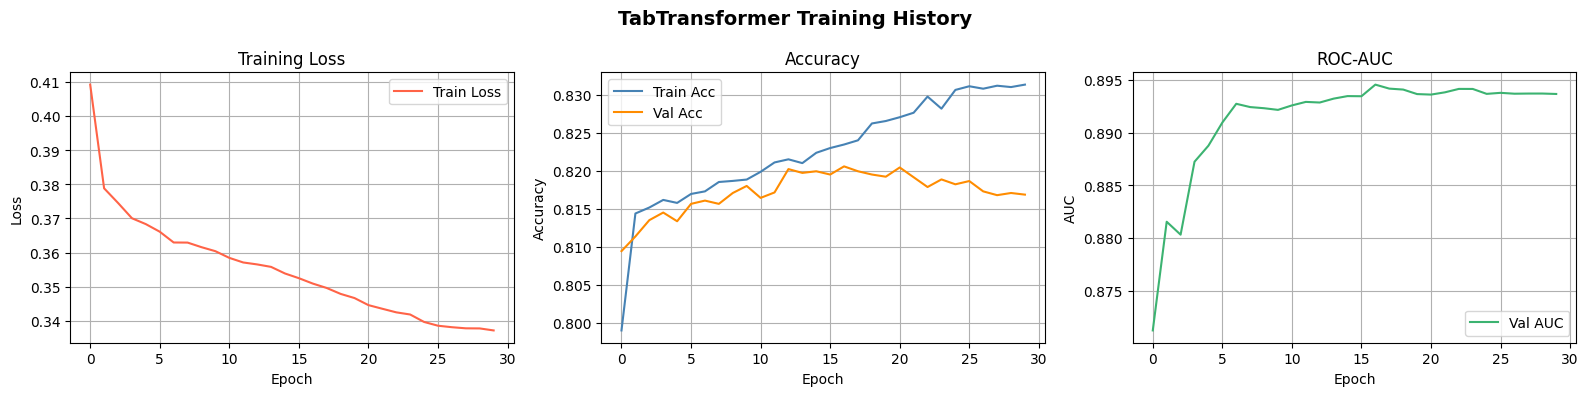

In [ ]:
# ── Training Curves ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], color="tomato", label="Train Loss")
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history["train_acc"], color="steelblue",  label="Train Acc")
axes[1].plot(history["val_acc"],   color="darkorange",  label="Val Acc")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(True)

axes[2].plot(history["val_auc"], color="mediumseagreen", label="Val AUC")
axes[2].set_title("ROC-AUC"); axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC"); axes[2].legend(); axes[2].grid(True)

plt.suptitle("TabTransformer Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### TabTransformer vs FT-Transformer — Key Differences

| | **TabTransformer** | **FT-Transformer** |
|---|---|---|
| **Categorical** | Dedicated embedding per feature → Transformer | All features tokenised uniformly |
| **Continuous** | LayerNorm → concat (no attention) | Projected to same d_model → attends with cats |
| **Paper** | Huang et al. 2020 | Gorishniy et al. 2021 |
| **Strength** | Explicit cat/cont split | Full cross-feature attention |


## SHAP Analysis — TabTransformer

`shap.GradientExplainer` ব্যবহার করা হচ্ছে।  
**Gradient clipping** (`clip_grad_norm_`, max_norm=1.0) শুধু training loop-এ — SHAP inference-এ কোনো প্রভাব নেই।

In [ ]:
import os
os.makedirs('shap_plots_tabtransformer', exist_ok=True)
os.chdir('shap_plots_tabtransformer')
print('PNG files will be saved in: shap_plots_tabtransformer/')


PNG files will be saved in: shap_plots_tabtransformer/


### Step 1 — Model Wrapper & Background Dataset

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TabTransformer takes (x_cat, x_cont) separately.
# GradientExplainer needs single tensor input → wrap the model.
class TabTransformerWrapper(torch.nn.Module):
    def __init__(self, model, n_cat):
        super().__init__()
        self.model = model
        self.n_cat  = n_cat
    def forward(self, x):
        x_cat  = x[:, :self.n_cat].long()
        x_cont = x[:, self.n_cat:].float()
        return self.model(x_cat, x_cont)

n_cat         = cat_tr.shape[1]
wrapped_model = TabTransformerWrapper(model, n_cat).to(device)
wrapped_model.eval()

# Background: 100 random training samples (cat + cont concatenated)
bg_idx     = np.random.choice(len(cat_tr), size=100, replace=False)
background = torch.cat([cat_tr[bg_idx].float(),
                         cont_tr[bg_idx].float()], dim=1).to(device)

tab_explainer = shap.GradientExplainer(wrapped_model, background)
print('GradientExplainer ready.')
print(f'Background shape : {background.shape}')


GradientExplainer ready.
Background shape : torch.Size([100, 22])


### Step 2 — Compute SHAP Values (500 Test Samples)

In [ ]:
N_EXPLAIN = 500
X_explain = torch.cat([cat_te[:N_EXPLAIN].float(),
                        cont_te[:N_EXPLAIN].float()], dim=1).to(device)

shap_vals_raw = tab_explainer.shap_values(X_explain)

# Class-1 (cardio=1) SHAP values → shape (N_EXPLAIN, n_features)
shap_vals_tab = (shap_vals_raw[1]
                 if isinstance(shap_vals_raw, list)
                 else shap_vals_raw[:, :, 1])

X_explain_np  = X_explain.cpu().numpy()
feature_names = CAT_FEATURES + CONT_FEATURES

print(f'SHAP values shape : {shap_vals_tab.shape}')
print(f'Features ({len(feature_names)}) : {feature_names}')


SHAP values shape : (500, 22)
Features (22) : ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi_category', 'map_category', 'age_category', 'bp_category', 'height', 'weight', 'ap_hi', 'ap_lo', 'age_years', 'bmi', 'pulse_pressure', 'health_index', 'cholesterol_gluc_interaction', 'map', 'metabolic_risk', 'bp_risk']


### SHAP Summary Plot (Bar) — Global Feature Importance

/tmp/ipykernel_2223/2289014304.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved: shap_bar_tabtransformer.png


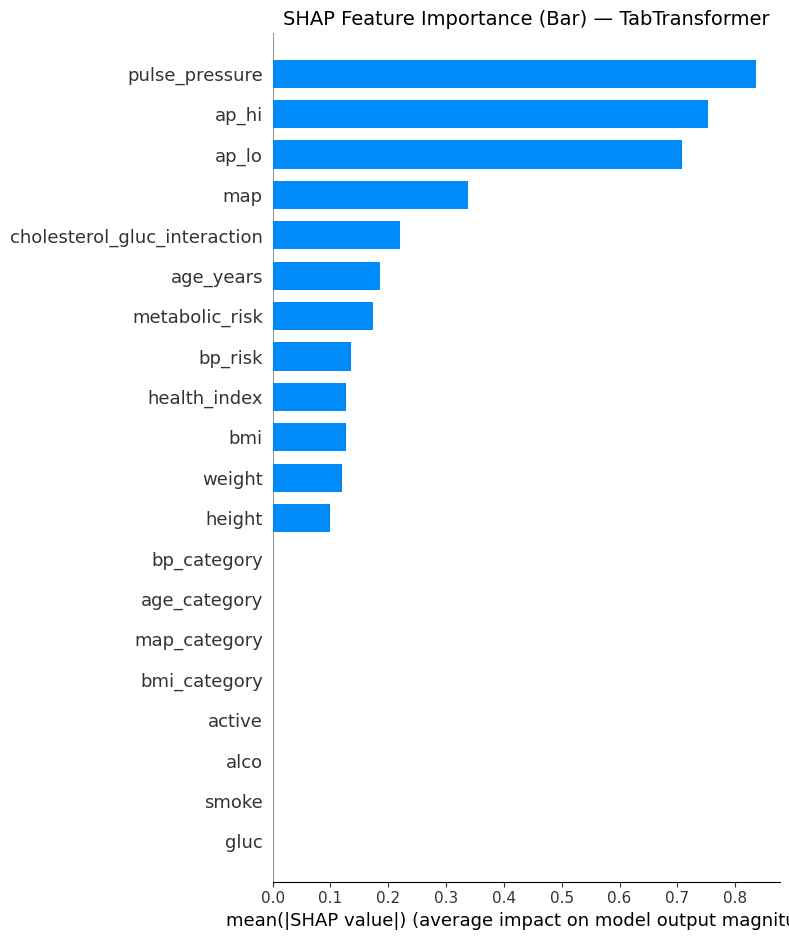

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_tab, X_explain_np,
    feature_names=feature_names,
    plot_type='bar', show=False
)
plt.title('SHAP Feature Importance (Bar) — TabTransformer', fontsize=14)
plt.tight_layout()
plt.savefig("shap_bar_tabtransformer.png", dpi=150, bbox_inches="tight")
print(f"Saved: shap_bar_tabtransformer.png")
plt.show()


### SHAP Summary Plot (Beeswarm) — Feature Impact Distribution

/tmp/ipykernel_2223/545976508.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved: shap_beeswarm_tabtransformer.png


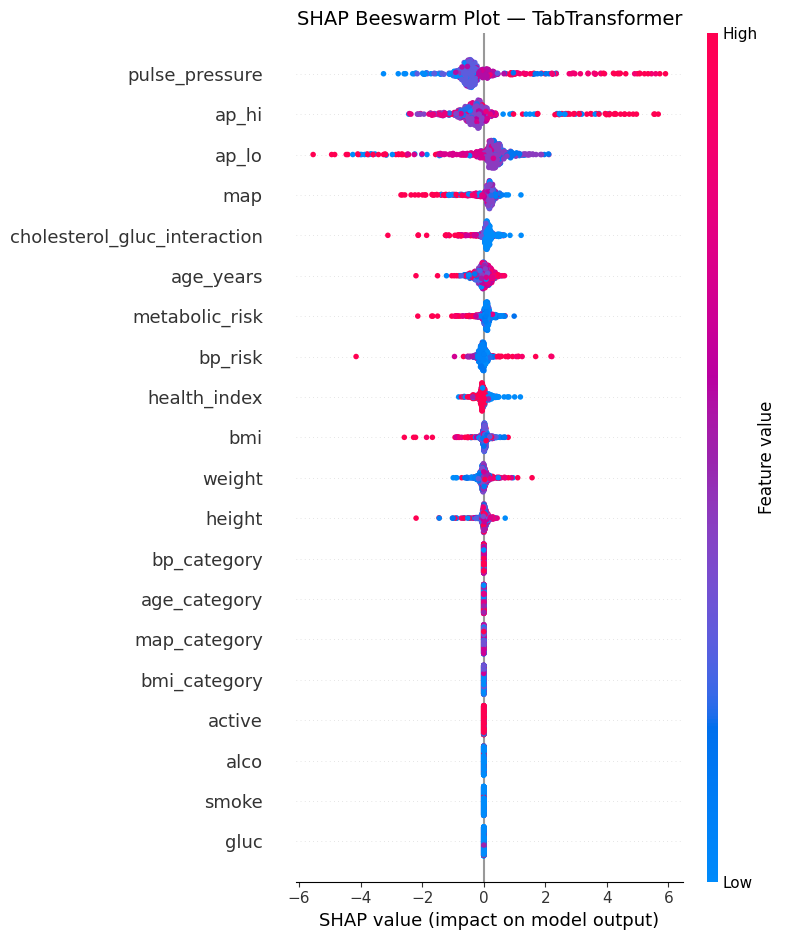

In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_tab, X_explain_np,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Beeswarm Plot — TabTransformer', fontsize=14)
plt.tight_layout()
plt.savefig("shap_beeswarm_tabtransformer.png", dpi=150, bbox_inches="tight")
print(f"Saved: shap_beeswarm_tabtransformer.png")
plt.show()


### Step 3 — Top 6 Features by Mean |SHAP|

In [ ]:
mean_shap = np.abs(shap_vals_tab).mean(axis=0)
top6 = (pd.Series(mean_shap, index=feature_names)
          .sort_values(ascending=False)
          .head(6))
print('Top 6 features (TabTransformer):')
print(top6)
top6_names = top6.index.tolist()


Top 6 features (TabTransformer):
pulse_pressure                  0.835744
ap_hi                           0.753370
ap_lo                           0.707553
map                             0.337225
cholesterol_gluc_interaction    0.219565
age_years                       0.185297
dtype: float64


### SHAP Dependence Plot — Feature 1 of Top 6

<Figure size 900x500 with 0 Axes>

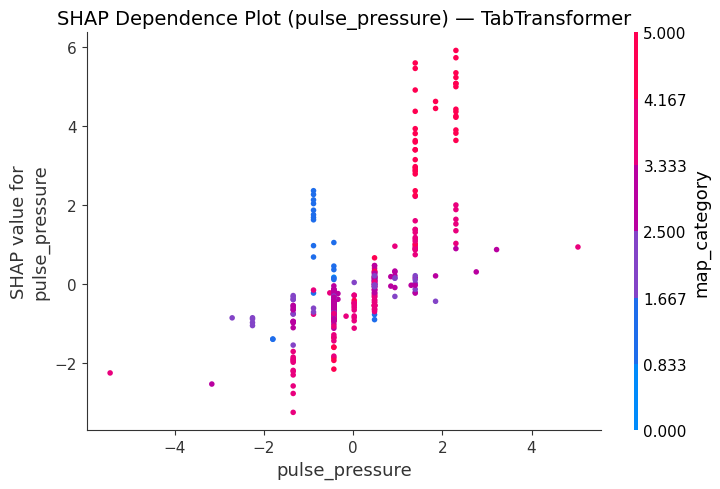

In [ ]:
feat = top6_names[0]; feat_idx = feature_names.index(feat)
plt.figure(figsize=(9, 5))
shap.dependence_plot(feat_idx, shap_vals_tab, X_explain_np,
                     feature_names=feature_names, show=False)
plt.title(f'SHAP Dependence Plot ({feat}) — TabTransformer', fontsize=14)
plt.tight_layout(); plt.show()


### SHAP Dependence Plot — Feature 2 of Top 6

<Figure size 900x500 with 0 Axes>

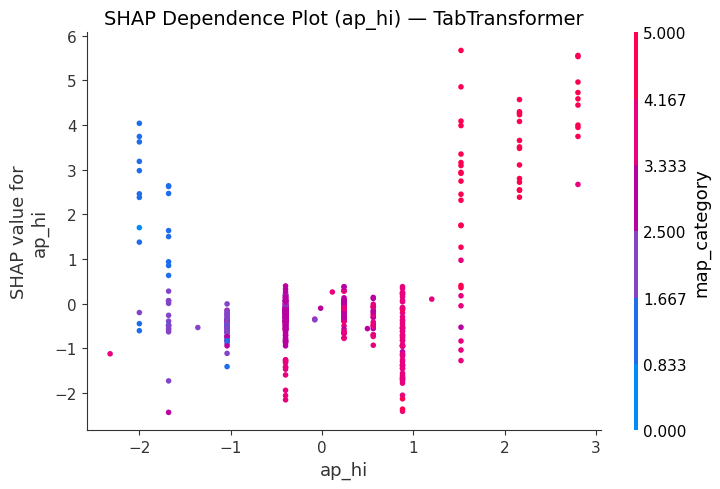

In [ ]:
feat = top6_names[1]; feat_idx = feature_names.index(feat)
plt.figure(figsize=(9, 5))
shap.dependence_plot(feat_idx, shap_vals_tab, X_explain_np,
                     feature_names=feature_names, show=False)
plt.title(f'SHAP Dependence Plot ({feat}) — TabTransformer', fontsize=14)
plt.tight_layout(); plt.show()


### SHAP Dependence Plot — Feature 3 of Top 6

<Figure size 900x500 with 0 Axes>

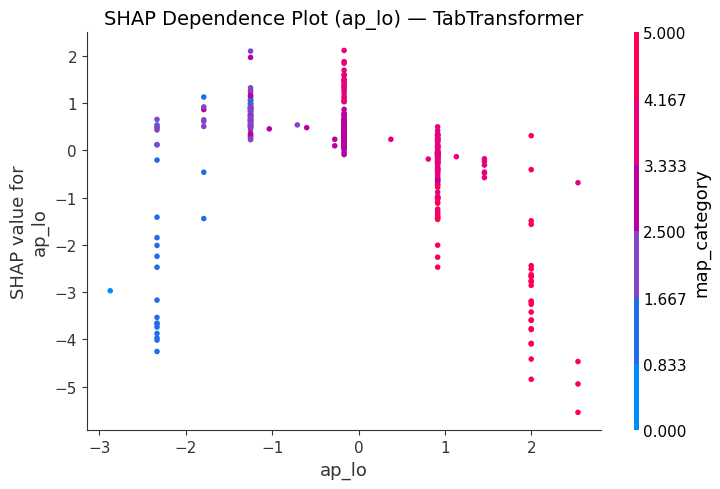

In [ ]:
feat = top6_names[2]; feat_idx = feature_names.index(feat)
plt.figure(figsize=(9, 5))
shap.dependence_plot(feat_idx, shap_vals_tab, X_explain_np,
                     feature_names=feature_names, show=False)
plt.title(f'SHAP Dependence Plot ({feat}) — TabTransformer', fontsize=14)
plt.tight_layout(); plt.show()


### SHAP Dependence Plot — Feature 4 of Top 6

<Figure size 900x500 with 0 Axes>

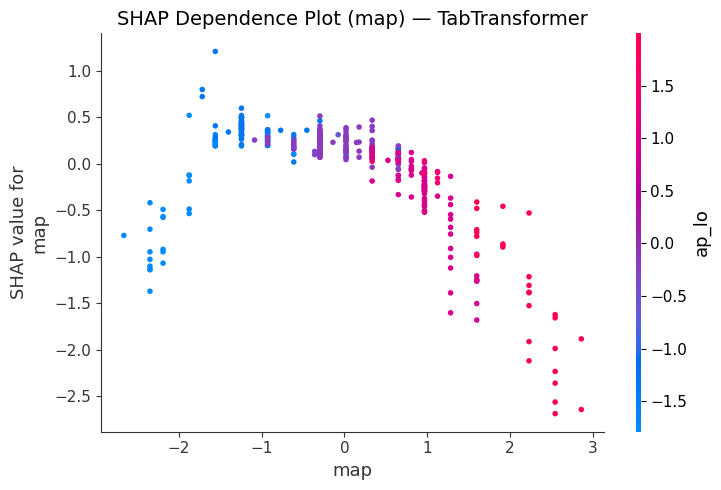

In [ ]:
feat = top6_names[3]; feat_idx = feature_names.index(feat)
plt.figure(figsize=(9, 5))
shap.dependence_plot(feat_idx, shap_vals_tab, X_explain_np,
                     feature_names=feature_names, show=False)
plt.title(f'SHAP Dependence Plot ({feat}) — TabTransformer', fontsize=14)
plt.tight_layout(); plt.show()


### SHAP Dependence Plot — Feature 5 of Top 6

<Figure size 900x500 with 0 Axes>

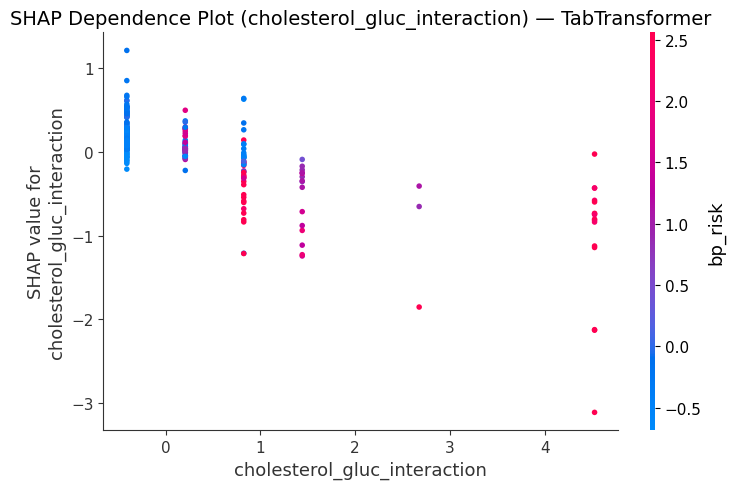

In [ ]:
feat = top6_names[4]; feat_idx = feature_names.index(feat)
plt.figure(figsize=(9, 5))
shap.dependence_plot(feat_idx, shap_vals_tab, X_explain_np,
                     feature_names=feature_names, show=False)
plt.title(f'SHAP Dependence Plot ({feat}) — TabTransformer', fontsize=14)
plt.tight_layout(); plt.show()


# SHAP Dependence Plot — Feature 6 of Top 6

<Figure size 900x500 with 0 Axes>

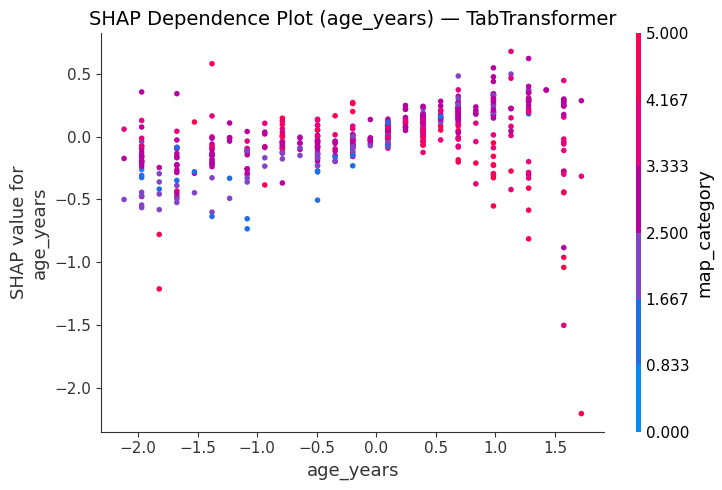

In [ ]:
feat = top6_names[5]; feat_idx = feature_names.index(feat)
plt.figure(figsize=(9, 5))
shap.dependence_plot(feat_idx, shap_vals_tab, X_explain_np,
                     feature_names=feature_names, show=False)
plt.title(f'SHAP Dependence Plot ({feat}) — TabTransformer', fontsize=14)
plt.tight_layout(); plt.show()


### SHAP Dependence Plot — MAP Feature (TabTransformer)

Saved: shap_dep_map_tabtransformer.png


<Figure size 900x500 with 0 Axes>

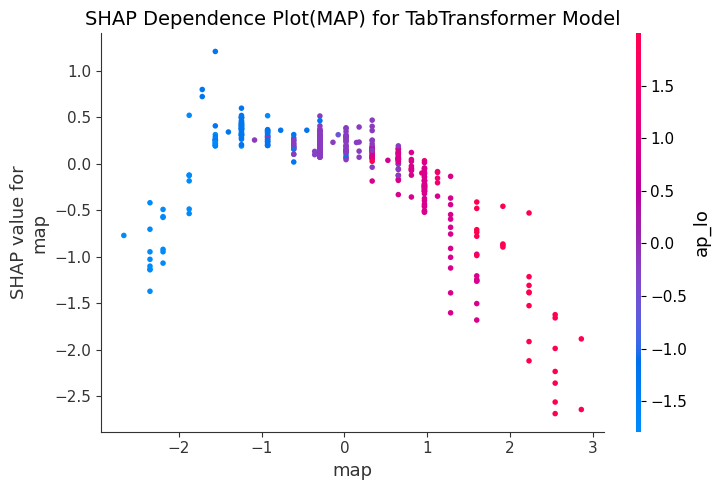

In [ ]:
plt.figure(figsize=(9, 5))
shap.dependence_plot(
    feature_names.index('map'),
    shap_vals_tab, X_explain_np,
    feature_names=feature_names, show=False
)
plt.title('SHAP Dependence Plot(MAP) for TabTransformer Model', fontsize=14)
plt.tight_layout()
plt.savefig("shap_dep_map_tabtransformer.png", dpi=150, bbox_inches="tight")
print(f"Saved: shap_dep_map_tabtransformer.png")
plt.show()


### SHAP Force Plot — Single Prediction Explanation (TabTransformer)

Saved: shap_force_tabtransformer.png


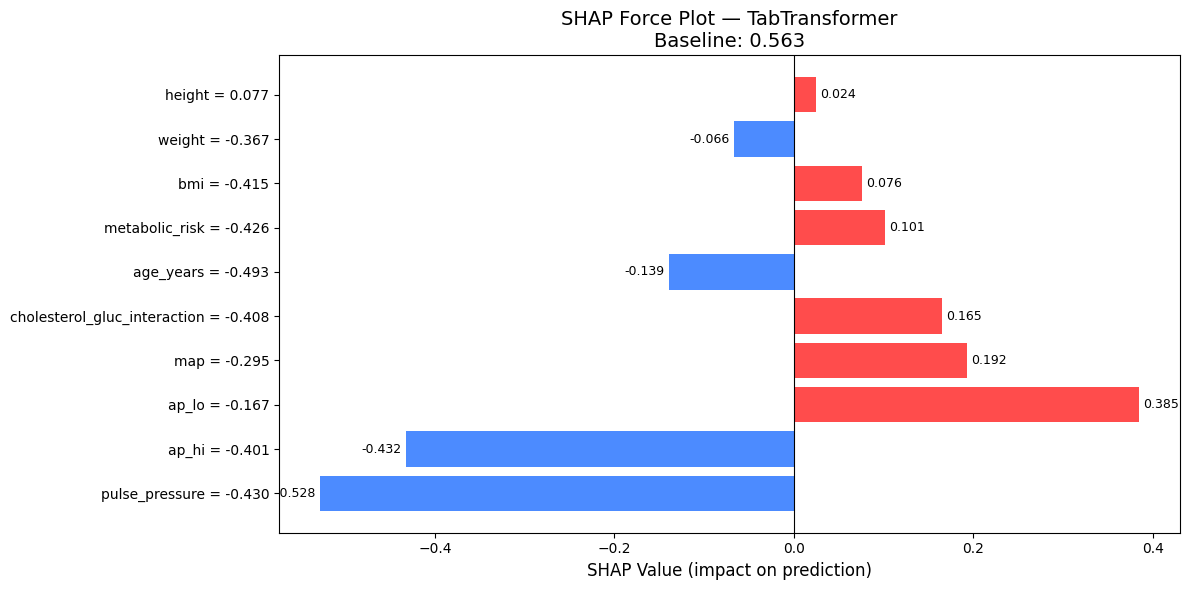

In [ ]:
wrapped_model.eval()
with torch.no_grad():
    bg_probs     = torch.softmax(wrapped_model(background), dim=1)[:, 1]
    expected_val = float(bg_probs.mean().cpu())

sample      = X_explain_np[0]
shap_sample = shap_vals_tab[0]

# Top 10 by absolute SHAP
top_idx    = np.argsort(np.abs(shap_sample))[-10:][::-1]
top_shap   = shap_sample[top_idx]
top_labels = [f"{feature_names[i]} = {sample[i]:.3f}" for i in top_idx]

# Manual waterfall-style force plot
colors = ['#FF4C4C' if v > 0 else '#4C8BFF' for v in top_shap]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_labels, top_shap, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value (impact on prediction)', fontsize=12)
ax.set_title('SHAP Force Plot — TabTransformer\n'
             f'Baseline: {expected_val:.3f}', fontsize=14)

for bar, val in zip(bars, top_shap):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9)

plt.tight_layout()
plt.savefig("shap_force_tabtransformer.png", dpi=150, bbox_inches="tight")
print("Saved: shap_force_tabtransformer.png")
plt.show()

In [ ]:
import shutil
from google.colab import files

shutil.make_archive('shap_plots_tabtransformer', 'zip', '/content', 'shap_plots_tabtransformer')
files.download('shap_plots_tabtransformer.zip')